In [1]:
%pip install ogb
%pip install EoN
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
%pip install torch_geometric



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 5.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for EoN: filename=EoN-1.2-py3-none-any.whl size=122468 sha256=2fd9b9ff788f2178cde323e4ef3a8735d47b5e855346317768c0db1c6e7bd569
  Stored in directory: /root/.cache/pip/wheels/53/e8/9d/8cce28ba7bdd58b1859da5582e7ca593ceae00cf9c996a3467
Successfully built EoN
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 60.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


# Config

In [2]:
config = {
    "undirected": True,

    "model": {
        "emb_dim": 256,
        "num_layers": [8],
        "dropout": 0.2,

        "conv_type": ["gcn","gin","gatv2"],
        "num_heads": 2,

        # Multiple pooling strategies
        "pool_types": ["mean"],

        "use_residual": False,
        "use_graph_norm": False,
    },

    "train": {
        "batch_size": 32,
        "epochs": 20,
        "lr": 1e-4,
        "weight_decay": 1e-5,
        "grad_clip": 1.0,
    },

    "data": {
        "max_depth": 20,
        "num_workers": 4,
    },

    "exp": {
        "seed": 42,
        "device": "cuda",
        "log_every": 50,
    }
}

# Data Loading

In [3]:
from ogb.graphproppred import PygGraphPropPredDataset
from torch_geometric.data import DataLoader
import torch
import torch_geometric
torch.serialization.add_safe_globals([torch_geometric.data.data.DataEdgeAttr, torch_geometric.data.data.DataTensorAttr,torch_geometric.data.storage.GlobalStorage])

from torch_geometric.utils import to_undirected

def make_undirected_transform(data):
    if config["undirected"]:
        data.edge_index = to_undirected(
            data.edge_index,
            num_nodes=data.num_nodes
        )
    return data

d_name= "ogbg-code2"
dataset = PygGraphPropPredDataset(name = d_name, pre_transform=make_undirected_transform)

split_idx = dataset.get_idx_split()
train_loader = DataLoader(dataset[split_idx["train"]], batch_size=config["train"]["batch_size"], shuffle=True)
valid_loader = DataLoader(dataset[split_idx["valid"]], batch_size=config["train"]["batch_size"], shuffle=False)
test_loader = DataLoader(dataset[split_idx["test"]], batch_size=config["train"]["batch_size"], shuffle=False)

Downloaded 0.91 GB: 100%|██████████| 934/934 [00:26<00:00, 34.86it/s]


Extracting dataset/code2.zip


Processing...


Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 452741/452741 [00:01<00:00, 388402.45it/s]


Converting graphs into PyG objects...


100%|██████████| 452741/452741 [00:14<00:00, 32285.55it/s]


Saving...


Done!
/tmp/ipykernel_55/3510622048.py:21: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(dataset[split_idx["train"]], batch_size=config["train"]["batch_size"], shuffle=True)
/tmp/ipykernel_55/3510622048.py:22: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  valid_loader = DataLoader(dataset[split_idx["valid"]], batch_size=config["train"]["batch_size"], shuffle=False)
/tmp/ipykernel_55/3510622048.py:23: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(dataset[split_idx["test"]], batch_size=config["train"]["batch_size"], shuffle=False)


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
import os
node_attr_path = os.path.join(os.curdir,dataset.root,"mapping","attridx2attr.csv.gz")
type_idx_path = os.path.join(os.curdir,dataset.root,"mapping","typeidx2type.csv.gz")

In [6]:
import os
import pandas as pd

node_attr_mapping  =  pd.read_csv(node_attr_path)
type_idx_mapping = pd.read_csv(type_idx_path)
node_type_vocab_size = len(type_idx_mapping)

In [7]:
new_rows = pd.DataFrame([{'attr idx': 10030, 'attr': '<pad>'},{'attr idx':10031,'attr':'<sos>'},{'attr idx':10032,'attr':'<eos>'}])
node_attr_mapping = pd.concat([node_attr_mapping, new_rows], ignore_index=True)

In [8]:
node_attr_to_idx_dict = {}
node_idx_to_attr_dict = {}
for i in range(len(node_attr_mapping)):
  node_attr_to_idx_dict[node_attr_mapping.iloc[i]['attr']] = node_attr_mapping.iloc[i]["attr idx"]
  node_idx_to_attr_dict[node_attr_mapping.iloc[i]["attr idx"]] = node_attr_mapping.iloc[i]["attr"]


# Encoder

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import (
    GINConv, GCNConv, GATv2Conv,DirGNNConv,
    GraphNorm,
    global_add_pool, global_mean_pool, global_max_pool,
    GlobalAttention,
    Set2Set # Added Set2Set import
)
class MultiHeadGlobalAttention(nn.Module):
    def __init__(self, emb_dim, heads=4):
        super().__init__()
        self.heads = heads

        self.gate_nn = nn.ModuleList([
            nn.Sequential(
                nn.Linear(emb_dim, 2*emb_dim),
                nn.LayerNorm(2*emb_dim),
                nn.ReLU(),
                nn.Linear(2*emb_dim, 1)
            )
            for _ in range(heads)
        ])

    def forward(self, x, batch):
        out = []

        for gate in self.gate_nn:
            scores = gate(x)                       # [N, 1]
            weights = torch_geometric.utils.softmax(scores, batch)
            pooled = torch_geometric.nn.global_add_pool(x * weights, batch)
            out.append(pooled)

        return torch.cat(out, dim=-1)

# ---------- Conv Factory ----------


def build_conv(conv_type, emb_dim, heads=2):
    if conv_type == "gin":
        mlp = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, emb_dim)
        )
        return GINConv(nn=mlp, train_eps=True)

    elif conv_type == "dir_gatv2":
        base_conv = GATv2Conv(
            emb_dim,
            emb_dim ,
            heads,
            concat=False
        )
        return DirGNNConv(base_conv)
        
    elif conv_type == "dir_gin":
        mlp = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, emb_dim)
        )
        base_conv = GINConv(nn=mlp, train_eps=True)
        base_conv.in_channels = emb_dim
        base_conv.out_channels = emb_dim
        return DirGNNConv(base_conv)
        
    elif conv_type == "dir_gcn":
        base_conv = GCNConv(emb_dim,emb_dim)
        return DirGNNConv(base_conv)

    elif conv_type == "gcn":
        return GCNConv(emb_dim, emb_dim)

    elif conv_type == "gatv2":
        assert emb_dim % heads == 0
        return GATv2Conv(
            emb_dim,
            emb_dim//2,
            heads=heads,
            concat=True
        )

    else:
        raise ValueError(f"Unknown conv type: {conv_type}")

def build_pool(pool_type, emb_dim, use_multi_stat=False, attn_heads=2):

    if pool_type == 'multi_stat':
        def pool(x, batch):
            return torch.cat([
                global_mean_pool(x, batch),
                global_max_pool(x, batch),
                global_add_pool(x, batch)
            ], dim=-1)
        return pool, emb_dim * 3

    if pool_type == "add":
        return lambda x, batch: global_add_pool(x, batch), emb_dim

    elif pool_type == "mean":
        return lambda x, batch: global_mean_pool(x, batch), emb_dim

    elif pool_type == "attention":
        if attn_heads == 1:
            gate_nn = nn.Sequential(
                nn.Linear(emb_dim, 2*emb_dim),
                nn.LayerNorm(2*emb_dim),
                nn.ReLU(),
                nn.Linear(2*emb_dim, 1)
            )
            return GlobalAttention(gate_nn), emb_dim
        else:
            pool = MultiHeadGlobalAttention(emb_dim, heads=attn_heads)
            return pool, emb_dim * attn_heads

    elif pool_type == "set2set":
        pool = Set2Set(emb_dim, processing_steps=3)
        return pool, emb_dim * 2

    else:
        raise ValueError(f"Unknown pool type: {pool_type}")

# ---------- Encoder ----------
class Encoder(nn.Module):
    def __init__(
        self,
        type_id_vocab_size,
        attr_id_vocab_size,
        max_depth,
        emb_dim,
        num_layers=3,
        conv_type="gin",
        pool_type="mean",
        dropout=0.2,
        num_heads=2,
        use_virtual_node=False,
        use_depth = True,
        use_residual = True,
        use_graph_norm = True
    ):
        super().__init__()

        self.emb_dim = emb_dim
        self.max_depth = max_depth
        self.num_layers = num_layers
        self.dropout = dropout
        self.use_virtual_node = use_virtual_node
        self.use_depth = use_depth
        self.use_residual = use_residual
        self.use_graph_norm = use_graph_norm

        # ---- Embeddings ----
        self.type_emb = nn.Embedding(type_id_vocab_size, emb_dim)
        self.attr_emb = nn.Embedding(attr_id_vocab_size, emb_dim)
        if use_depth:
          self.depth_emb = nn.Embedding(max_depth + 1, emb_dim)

          self.input_proj = nn.Linear(3 * emb_dim, emb_dim)
        else:
          self.input_proj = nn.Linear(2 * emb_dim, emb_dim)

        # ---- Conv stack ----
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        for _ in range(num_layers):
            self.convs.append(build_conv(conv_type, emb_dim, num_heads))
            self.norms.append(GraphNorm(emb_dim))

        # ---- Virtual Node ----
        if use_virtual_node:
            self.virtual_node_emb = nn.Embedding(1, emb_dim)
            self.virtual_mlp = nn.Sequential(
                nn.Linear(emb_dim, emb_dim),
                nn.ReLU(),
                nn.Linear(emb_dim, emb_dim)
            )

        # ---- Pooling ----
        self.pool, self.pool_dim = build_pool(
            pool_type, emb_dim
        )
        self.fc_out = nn.Sequential(nn.Linear(self.pool_dim,emb_dim*2),nn.ReLU(),nn.LayerNorm(emb_dim*2),nn.Linear(emb_dim*2,emb_dim),nn.LayerNorm(emb_dim))

    def forward(self, x, edge_index, depth, batch):
        # ---- Unpack ----
        type_ids = x[:, 0]
        attr_ids = x[:, 1]
        node_depth = torch.clamp(depth.squeeze(-1), 0, self.max_depth)

        # ---- Embed ----
        x1 = self.type_emb(type_ids)
        x2 = self.attr_emb(attr_ids)
        if self.use_depth:
          x3 = self.depth_emb(node_depth)
          x = torch.cat([x1, x2, x3], dim=1)
        else:
          x = torch.cat([x1, x2], dim=1)
        x = self.input_proj(x)

        # ---- Init virtual node ----
        if self.use_virtual_node:
            num_graphs = batch.max().item() + 1
            virtual_node = self.virtual_node_emb.weight.repeat(num_graphs, 1)

        # ---- Message Passing ----
        for layer, (conv, norm) in enumerate(zip(self.convs, self.norms)):

            # Add virtual node to all nodes
            if self.use_virtual_node:
                x = x + virtual_node[batch]

            h = conv(x, edge_index)
            h = F.elu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)

            if self.use_residual:
                x = x + h
            if self.use_graph_norm:
                x = norm(x)

            # Update virtual node
            if self.use_virtual_node:
                pooled = global_add_pool(x, batch)
                virtual_node = virtual_node + self.virtual_mlp(pooled)

        # ---- Pooling ----
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.pool(x, batch)
        x = self.fc_out(x)

        return x

# Decoder

In [10]:
import torch
import torch.nn as nn
import math

class GraphConditionedTransformerDecoder(nn.Module):
    def __init__(
        self,
        embedding,
        vocab_size,
        emb_dim,
        pad_token_id,
        num_layers=4,
        nhead=4,
        max_len=20,
        dropout=0.1
    ):
        super().__init__()

        self.emb_dim = emb_dim
        self.embedding = embedding
        self.pad_token_id = pad_token_id

        # Positional embedding
        self.pos_emb = nn.Embedding(max_len, emb_dim)

        self.graph_ln = nn.LayerNorm(emb_dim)

        decoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            nhead=nhead,
            batch_first=True,
            dropout=dropout
        )

        self.transformer = nn.TransformerEncoder(decoder_layer, num_layers)

        # Output projection (weight tying, no bias)
        self.fc_out = nn.Linear(emb_dim, vocab_size, bias=False)
        self.fc_out.weight = self.embedding.weight

    def forward(self, graph_emb, tgt):
        """
        graph_emb: [B, H]
        tgt: [B, T]
        """

        B, T = tgt.shape

        # Token embeddings
        tok_emb = self.embedding(tgt) * math.sqrt(self.emb_dim)

        pos = torch.arange(T, device=tgt.device).unsqueeze(0)
        pos_emb = self.pos_emb(pos)

        x = tok_emb + pos_emb  # [B, T, H]

        graph_token = graph_emb.unsqueeze(1)  # [B, 1, H] 

        x = torch.cat([graph_token, x], dim=1)  # [B, T+1, H]

        seq_len = x.size(1)

        mask = torch.triu(
            torch.ones(seq_len, seq_len, device=x.device),
            diagonal=1
        )
        mask = mask.masked_fill(mask == 1, float('-inf')).masked_fill(mask == 0, 0.0)

        mask[:, 0] = 0

        padding_mask = (tgt == self.pad_token_id)  # [B, T]

        graph_pad = torch.zeros((B, 1), dtype=torch.bool, device=tgt.device)

        padding_mask = torch.cat([graph_pad, padding_mask], dim=1)  # [B, T+1]

        x = self.transformer(
            x,
            mask=mask,
            src_key_padding_mask=padding_mask
        )

        # Remove graph token
        x = x[:, 1:, :]  # [B, T, H]

        logits = self.fc_out(x)

        return logits

# Graph2Seq

In [11]:
import torch
import torch.nn as nn

class Graph2SeqModel(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, data, tgt):
        graph_emb = self.encoder(
            data.x.to(device),
            data.edge_index.to(device),
            data.node_depth.to(device),
            data.batch.to(device)
        )

        logits = self.decoder(graph_emb, tgt)

        return logits

    def generate(self, data, max_tokens):
        graph_emb = self.encoder(
            data.x.to(device),
            data.edge_index.to(device),
            data.node_depth.to(device),
            data.batch.to(device)
        )

        num_graphs_in_batch = data.num_graphs

        tgt = torch.tensor([[10031] for i in range(num_graphs_in_batch)], device=device)

        for i in range(max_tokens):
            logits = self.decoder(graph_emb, tgt)
            next_token = torch.argmax(logits[:, -1, :], dim=1)
            tgt = torch.cat([tgt, next_token.unsqueeze(-1)], dim=1)

        return tgt

## Error Analysis by Graph Topology

In [12]:
from pathlib import Path
import torch
import numpy as np
import pandas as pd
from torch_geometric.utils import degree
import networkx as nx
from tqdm import tqdm

PAD = 10030
SOS = 10031
EOS = 10032
UNK = 10029

# Explicit checkpoints for topology analysis.
analysis_checkpoint_names = [
    "/kaggle/input/models/shreyasarun29/ogbg-code2/pytorch/default/1/8_dir_gcn_attention.pt",
    "/kaggle/input/models/shreyasarun29/ogbg-code2/pytorch/default/1/8_dir_gin_attention.pt",
    "/kaggle/input/models/shreyasarun29/ogbg-code2/pytorch/default/1/8_gcn_attention.pt",
    "/kaggle/input/models/shreyasarun29/ogbg-code2/pytorch/default/1/8_gin_attention.pt",
]
analysis_checkpoint_glob = None  # Set to a glob like "*.pt" if you want auto-discovery.
analysis_max_tokens = 20
analysis_output_dir = Path("error_analysis_outputs")
analysis_output_dir.mkdir(parents=True, exist_ok=True)

def parse_checkpoint_name(checkpoint_name, known_pools=None):
    stem = Path(checkpoint_name).stem

    if "_" not in stem:
        raise ValueError(
            f"Checkpoint name '{checkpoint_name}' must follow <layers>_<conv>_<pool>.pt"
        )

    layers_str, remainder = stem.split("_", 1)

    try:
        layers = int(layers_str)
    except ValueError as exc:
        raise ValueError(
            f"Unable to parse layer count from checkpoint name '{checkpoint_name}'"
        ) from exc

    for pool in sorted(known_pools or [], key=len, reverse=True):
        suffix = f"_{pool}"
        if remainder.endswith(suffix):
            conv = remainder[: -len(suffix)]
            if conv:
                return layers, conv, pool

    if "_" not in remainder:
        raise ValueError(
            f"Unable to parse conv/pool from checkpoint name '{checkpoint_name}'"
        )

    conv, pool = remainder.rsplit("_", 1)
    if not conv or not pool:
        raise ValueError(
            f"Unable to parse conv/pool from checkpoint name '{checkpoint_name}'"
        )
    return layers, conv, pool


def list_analysis_checkpoints(pattern, known_pools):
    checkpoints = []
    skipped = []

    for checkpoint_path in sorted(Path(".").glob(pattern)):
        if not checkpoint_path.is_file():
            continue

        try:
            parse_checkpoint_name(checkpoint_path.name, known_pools=known_pools)
            checkpoints.append(checkpoint_path)
        except ValueError:
            skipped.append(checkpoint_path.name)

    return checkpoints, skipped


def load_analysis_model(checkpoint_path, device):
    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

    known_pools = {"add", "mean", "attention", "set2set", "multi_stat"}
    known_pools.update(config["model"].get("pool_types", []))

    layers, conv_type, pool_type = parse_checkpoint_name(
        checkpoint_path.name,
        known_pools=known_pools,
    )

    supported_conv_types = {"gin", "gcn", "gatv2", "dir_gin", "dir_gcn", "dir_gatv2"}
    if conv_type not in supported_conv_types:
        raise ValueError(
            f"Unsupported conv type '{conv_type}' parsed from '{checkpoint_path.name}'"
        )

    encoder = Encoder(
        type_id_vocab_size=node_type_vocab_size,
        attr_id_vocab_size=node_attr_mapping.shape[0],
        max_depth=config["data"]["max_depth"],
        emb_dim=config["model"]["emb_dim"],
        num_layers=layers,
        conv_type=conv_type,
        pool_type=pool_type,
        dropout=config["model"]["dropout"],
        num_heads=config["model"]["num_heads"],
        use_residual=config["model"]["use_residual"],
        use_graph_norm=config["model"]["use_graph_norm"],
    ).to(device)

    decoder = GraphConditionedTransformerDecoder(
        encoder.attr_emb,
        node_attr_mapping.shape[0],
        config["model"]["emb_dim"],
        PAD,
    ).to(device)

    loaded_model = Graph2SeqModel(encoder, decoder).to(device)
    state_dict = torch.load(checkpoint_path, map_location=device)
    loaded_model.load_state_dict(state_dict)
    loaded_model.eval()

    return loaded_model, layers, conv_type, pool_type


def per_graph_f1(ref_tokens, pred_tokens):
    """Token-level F1 for a single graph prediction."""
    ref_set = set(ref_tokens)
    pred_set = set(pred_tokens)
    if not pred_set or not ref_set:
        return 0.0
    tp = len(ref_set & pred_set)
    prec = tp / len(pred_set)
    rec = tp / len(ref_set)
    if prec + rec == 0:
        return 0.0
    return 2 * prec * rec / (prec + rec)


def collect_error_analysis_data(model, loader, device, max_batches=None, max_tokens=20):
    """
    For each graph in the loader, collect:
      - per-graph F1 score
      - structural features: num_nodes, num_edges, avg_degree, max_degree,
        tree_depth (from node_depth), is_connected, num_connected_components,
        branching_factor, fraction of each node type group
      - generation features: predicted length, reference length, length gap
    """
    model.eval()
    records = []
    type_idx_to_name = dict(zip(type_idx_mapping["type idx"], type_idx_mapping["type"]))

    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(loader, desc="Collecting")):
            if max_batches and batch_idx >= max_batches:
                break

            batch = batch.to(device)
            preds = model.generate(batch, max_tokens=max_tokens)
            y = batch.y

            ptr = batch.ptr.cpu()

            for i in range(batch.num_graphs):
                n_start = ptr[i].item()
                n_end = ptr[i + 1].item()
                num_nodes = n_end - n_start

                x_i = batch.x[n_start:n_end].cpu()
                depth_i = batch.node_depth[n_start:n_end].cpu().squeeze(-1)

                edge_mask = (batch.edge_index[0] >= n_start) & (batch.edge_index[0] < n_end)
                ei_i = batch.edge_index[:, edge_mask].cpu() - n_start
                num_edges = ei_i.size(1)

                deg = degree(ei_i[0], num_nodes=num_nodes).numpy()
                avg_deg = float(deg.mean()) if len(deg) > 0 else 0.0
                max_deg = float(deg.max()) if len(deg) > 0 else 0.0

                max_depth = float(depth_i.max().item()) if num_nodes > 0 else 0.0

                G = nx.DiGraph()
                G.add_nodes_from(range(num_nodes))
                if num_edges > 0:
                    G.add_edges_from(ei_i.T.tolist())
                G_undir = G.to_undirected()
                connected = nx.is_connected(G_undir) if num_nodes > 1 else True
                num_cc = nx.number_connected_components(G_undir)

                out_deg = np.array([d for _, d in G.out_degree()])
                non_leaf_deg = out_deg[out_deg > 0]
                branching = float(non_leaf_deg.mean()) if len(non_leaf_deg) > 0 else 1.0

                type_ids = x_i[:, 0].numpy() if x_i.dim() > 1 else x_i.numpy()
                unique_types, counts = np.unique(type_ids, return_counts=True)
                type_dist = {
                    type_idx_to_name.get(int(t), "unknown"): int(c)
                    for t, c in zip(unique_types, counts)
                }

                structural_types = {
                    "FunctionDef",
                    "ClassDef",
                    "Module",
                    "For",
                    "While",
                    "If",
                    "With",
                    "Try",
                    "ExceptHandler",
                    "AsyncFunctionDef",
                    "AsyncFor",
                    "AsyncWith",
                }
                identifier_types = {"Name", "Attribute", "arg", "Starred"}
                literal_types = {
                    "Num",
                    "Str",
                    "Bytes",
                    "NameConstant",
                    "Constant",
                    "List",
                    "Tuple",
                    "Dict",
                    "Set",
                }

                total = max(num_nodes, 1)
                frac_structural = sum(type_dist.get(t, 0) for t in structural_types) / total
                frac_identifier = sum(type_dist.get(t, 0) for t in identifier_types) / total
                frac_literal = sum(type_dist.get(t, 0) for t in literal_types) / total

                ref = list(y[i])
                pred_tok = []
                for j in range(len(preds[i])):
                    tok = preds[i][j].item()
                    pred_tok.append(node_idx_to_attr_dict.get(tok, "<unk>"))
                    if tok == EOS:
                        break
                pred_tok = [t for t in pred_tok if t not in ("<sos>", "<eos>", "<pad>")]
                f1 = per_graph_f1(ref, pred_tok)

                records.append(
                    {
                        "f1": f1,
                        "num_nodes": num_nodes,
                        "num_edges": num_edges,
                        "avg_degree": avg_deg,
                        "max_degree": max_deg,
                        "max_depth": max_depth,
                        "is_connected": int(connected),
                        "num_components": num_cc,
                        "branching": branching,
                        "frac_structural": frac_structural,
                        "frac_identifier": frac_identifier,
                        "frac_literal": frac_literal,
                        "pred_len": len(pred_tok),
                        "ref_len": len(ref),
                        "len_gap": len(pred_tok) - len(ref),
                    }
                )

    return pd.DataFrame(records)


known_pools = {"add", "mean", "attention", "set2set", "multi_stat"}
known_pools.update(config["model"].get("pool_types", []))

if analysis_checkpoint_names:
    checkpoint_paths = []
    missing_checkpoints = []
    invalid_checkpoints = []

    for checkpoint_name in analysis_checkpoint_names:
        checkpoint_path = Path(checkpoint_name)
        if not checkpoint_path.is_file():
            missing_checkpoints.append(checkpoint_name)
            continue

        try:
            parse_checkpoint_name(checkpoint_path.name, known_pools=known_pools)
            checkpoint_paths.append(checkpoint_path)
        except ValueError:
            invalid_checkpoints.append(checkpoint_name)

    skipped_checkpoints = []

    if missing_checkpoints:
        raise FileNotFoundError(
            "Missing checkpoint files:\n"
            + "\n".join(f"  - {name}" for name in missing_checkpoints)
        )

    if invalid_checkpoints:
        raise ValueError(
            "These checkpoints do not match <layers>_<conv>_<pool>.pt:\n"
            + "\n".join(f"  - {name}" for name in invalid_checkpoints)
        )
else:
    checkpoint_paths, skipped_checkpoints = list_analysis_checkpoints(
        analysis_checkpoint_glob or "*.pt",
        known_pools,
    )

if not checkpoint_paths:
    raise FileNotFoundError(
        "No checkpoints matched the required naming format <layers>_<conv>_<pool>.pt"
    )

analysis_results = {}
analysis_metadata = []

for checkpoint_path in checkpoint_paths:
    model, analysis_layers, analysis_conv, analysis_pool = load_analysis_model(
        checkpoint_path,
        device,
    )

    model_tag = checkpoint_path.stem
    print(
        f"\nRunning topology collection for {model_tag}.pt "
        f"(layers={analysis_layers}, conv={analysis_conv}, pool={analysis_pool})"
    )

    model_df = collect_error_analysis_data(
        model,
        test_loader,
        device,
        max_tokens=analysis_max_tokens,
    )
    model_df["model_tag"] = model_tag
    analysis_results[model_tag] = model_df

    analysis_metadata.append(
        {
            "model_tag": model_tag,
            "layers": analysis_layers,
            "conv": analysis_conv,
            "pool": analysis_pool,
            "num_graphs": len(model_df),
        }
    )

analysis_overview_df = pd.DataFrame(analysis_metadata).sort_values("model_tag").reset_index(drop=True)
df = pd.concat(analysis_results.values(), ignore_index=True)

if skipped_checkpoints:
    print("\nSkipped files (did not match naming convention):")
    for name in skipped_checkpoints:
        print(f"  - {name}")

print("\nLoaded checkpoints for analysis:")
print(analysis_overview_df.to_string(index=False))
print(f"\nCombined rows across all models: {len(df)}")
print(f"Plots will be saved under: {analysis_output_dir.resolve()}")


Running topology collection for 8_dir_gcn_attention.pt (layers=8, conv=dir_gcn, pool=attention)


Collecting:   0%|          | 0/686 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(
Collecting: 100%|██████████| 686/686 [01:40<00:00,  6.85it/s]



Running topology collection for 8_dir_gin_attention.pt (layers=8, conv=dir_gin, pool=attention)


Collecting:   0%|          | 0/686 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(
Collecting: 100%|██████████| 686/686 [01:39<00:00,  6.92it/s]



Running topology collection for 8_gcn_attention.pt (layers=8, conv=gcn, pool=attention)


Collecting:   0%|          | 0/686 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(
Collecting: 100%|██████████| 686/686 [01:38<00:00,  7.00it/s]



Running topology collection for 8_gin_attention.pt (layers=8, conv=gin, pool=attention)


Collecting:   0%|          | 0/686 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(
Collecting: 100%|██████████| 686/686 [01:35<00:00,  7.20it/s]



Loaded checkpoints for analysis:
          model_tag  layers    conv      pool  num_graphs
8_dir_gcn_attention       8 dir_gcn attention       21948
8_dir_gin_attention       8 dir_gin attention       21948
    8_gcn_attention       8     gcn attention       21948
    8_gin_attention       8     gin attention       21948

Combined rows across all models: 87792
Plots will be saved under: /kaggle/working/error_analysis_outputs


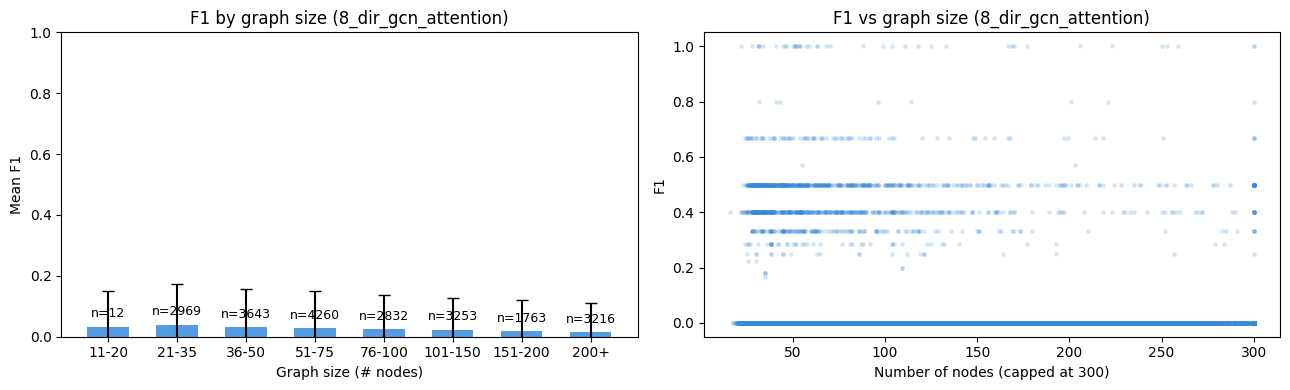


[8_dir_gcn_attention] graph size stats
    bin  mean_f1   std_f1  count
  11-20 0.033333 0.115470     12
  21-35 0.039935 0.134809   2969
  36-50 0.033172 0.122859   3643
  51-75 0.029453 0.119348   4260
 76-100 0.026488 0.110145   2832
101-150 0.023595 0.104880   3253
151-200 0.019893 0.100952   1763
   200+ 0.016835 0.095269   3216
Saved: error_analysis_outputs/8_dir_gcn_attention_error_analysis_graph_size.png


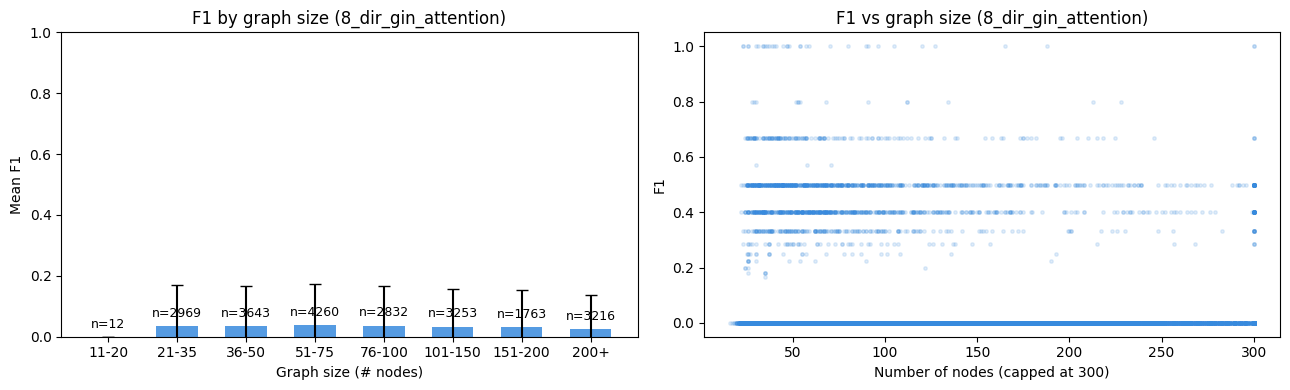


[8_dir_gin_attention] graph size stats
    bin  mean_f1   std_f1  count
  11-20 0.000000 0.000000     12
  21-35 0.036458 0.133604   2969
  36-50 0.035886 0.132277   3643
  51-75 0.039857 0.133930   4260
 76-100 0.036862 0.128362   2832
101-150 0.033514 0.123592   3253
151-200 0.031551 0.122113   1763
   200+ 0.026051 0.109567   3216
Saved: error_analysis_outputs/8_dir_gin_attention_error_analysis_graph_size.png


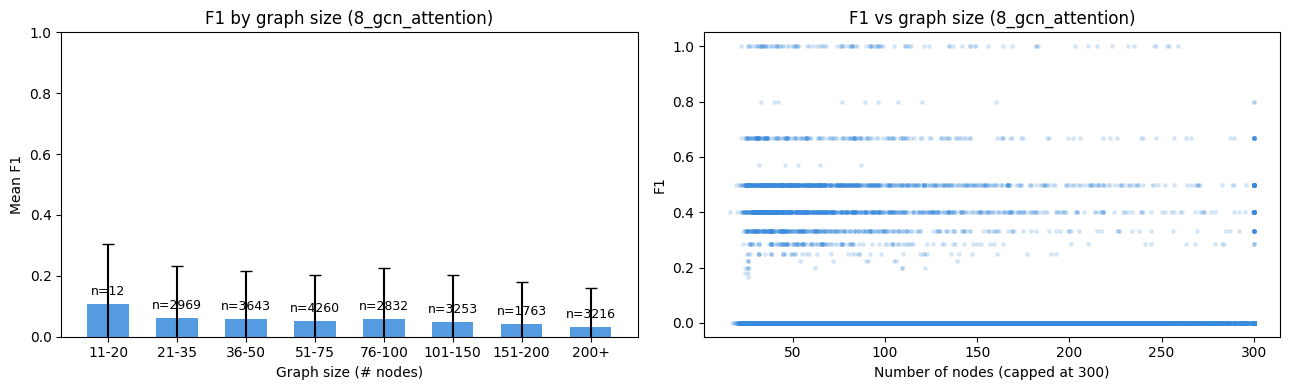


[8_gcn_attention] graph size stats
    bin  mean_f1   std_f1  count
  11-20 0.108333 0.197523     12
  21-35 0.061928 0.169385   2969
  36-50 0.057735 0.159296   3643
  51-75 0.052528 0.150735   4260
 76-100 0.057348 0.168599   2832
101-150 0.049160 0.152857   3253
151-200 0.041658 0.139152   1763
   200+ 0.032658 0.128511   3216
Saved: error_analysis_outputs/8_gcn_attention_error_analysis_graph_size.png


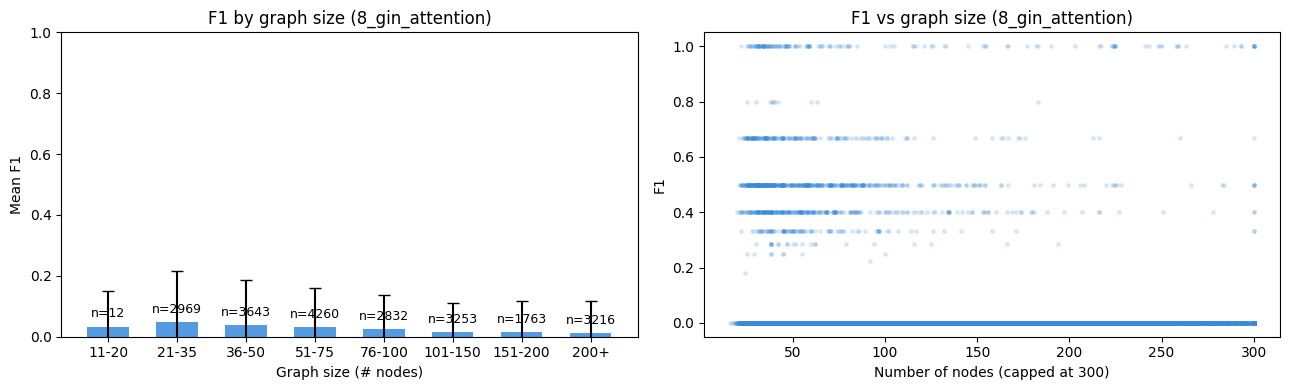


[8_gin_attention] graph size stats
    bin  mean_f1   std_f1  count
  11-20 0.033333 0.115470     12
  21-35 0.048726 0.168570   2969
  36-50 0.038354 0.147764   3643
  51-75 0.030496 0.130704   4260
 76-100 0.023980 0.113017   2832
101-150 0.015935 0.095833   3253
151-200 0.015941 0.101768   1763
   200+ 0.013381 0.105013   3216
Saved: error_analysis_outputs/8_gin_attention_error_analysis_graph_size.png


In [13]:
import matplotlib.pyplot as plt

for model_tag, model_df in analysis_results.items():
    df_plot = model_df.copy()

    # Bin graphs by number of nodes (finer buckets)
    df_plot["size_bin"] = pd.cut(
        df_plot["num_nodes"],
        bins=[0, 5, 10, 20, 35, 50, 75, 100, 150, 200, 9999],
        labels=["1-5", "6-10", "11-20", "21-35", "36-50", "51-75", "76-100", "101-150", "151-200", "200+"],
    )

    size_stats = (
        df_plot.groupby("size_bin", observed=True)["f1"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    size_stats.columns = ["bin", "mean_f1", "std_f1", "count"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Mean F1 by size bin
    ax = axes[0]
    bars = ax.bar(
        size_stats["bin"],
        size_stats["mean_f1"],
        yerr=size_stats["std_f1"],
        capsize=4,
        color="#378ADD",
        alpha=0.85,
        width=0.6,
    )
    ax.set_xlabel("Graph size (# nodes)")
    ax.set_ylabel("Mean F1")
    ax.set_title(f"F1 by graph size ({model_tag})")
    ax.set_ylim(0, 1)
    for bar, (_, row) in zip(bars, size_stats.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"n={int(row['count'])}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    # F1 vs num_nodes scatter
    ax = axes[1]
    ax.scatter(
        df_plot["num_nodes"].clip(upper=300),
        df_plot["f1"],
        alpha=0.15,
        s=6,
        color="#378ADD",
    )
    ax.set_xlabel("Number of nodes (capped at 300)")
    ax.set_ylabel("F1")
    ax.set_title(f"F1 vs graph size ({model_tag})")

    plt.tight_layout()
    output_path = analysis_output_dir / f"{model_tag}_error_analysis_graph_size.png"
    plt.savefig(output_path, dpi=150)
    plt.show()
    plt.close(fig)

    print(f"\n[{model_tag}] graph size stats")
    print(size_stats.to_string(index=False))
    print(f"Saved: {output_path}")

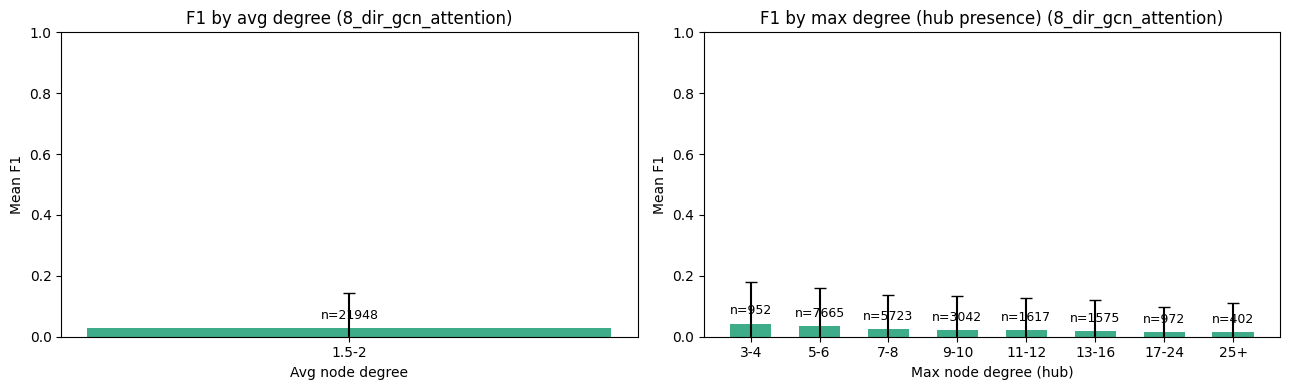


[8_dir_gcn_attention] degree stats
Average degree bins:
  bin  mean_f1   std_f1  count
1.5-2 0.027623 0.114572  21948

Max degree bins:
  bin  mean_f1   std_f1  count
  3-4 0.043370 0.137999    952
  5-6 0.033844 0.124943   7665
  7-8 0.026072 0.109839   5723
 9-10 0.023161 0.109335   3042
11-12 0.021183 0.104889   1617
13-16 0.019879 0.100316   1575
17-24 0.014266 0.084053    972
  25+ 0.016086 0.093163    402
Saved: error_analysis_outputs/8_dir_gcn_attention_error_analysis_degree.png


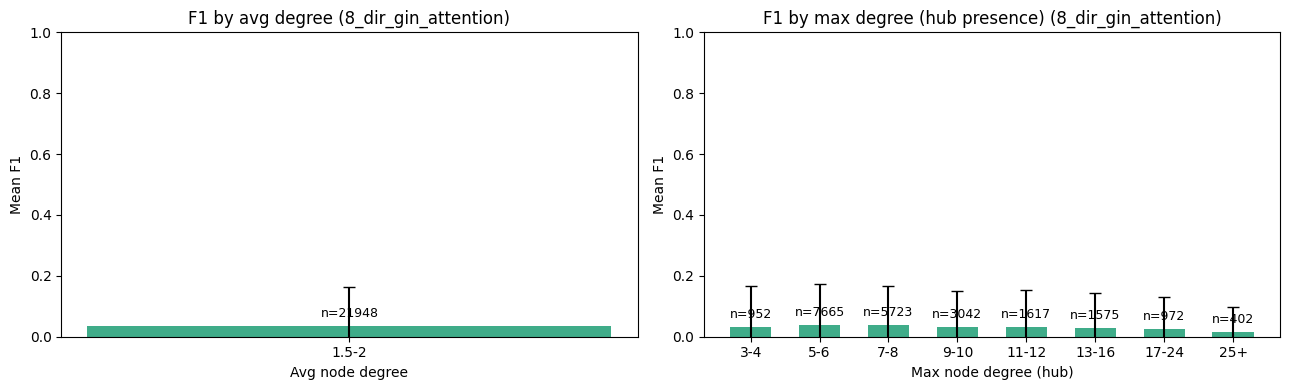


[8_dir_gin_attention] degree stats
Average degree bins:
  bin  mean_f1  std_f1  count
1.5-2   0.0347 0.12713  21948

Max degree bins:
  bin  mean_f1   std_f1  count
  3-4 0.032846 0.133320    952
  5-6 0.038575 0.134322   7665
  7-8 0.036962 0.130524   5723
 9-10 0.031372 0.120190   3042
11-12 0.032467 0.120747   1617
13-16 0.029101 0.114440   1575
17-24 0.023839 0.105104    972
  25+ 0.015352 0.082185    402
Saved: error_analysis_outputs/8_dir_gin_attention_error_analysis_degree.png


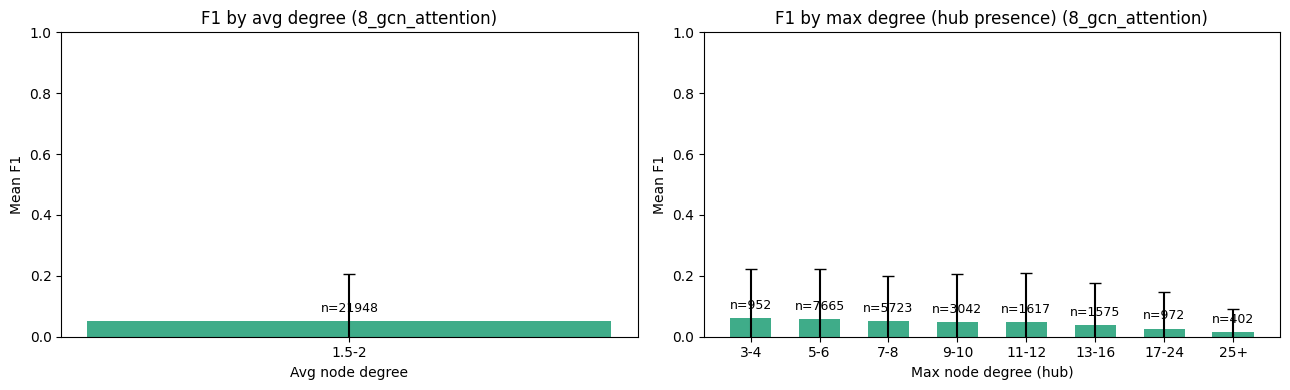


[8_gcn_attention] degree stats
Average degree bins:
  bin  mean_f1   std_f1  count
1.5-2 0.051033 0.153982  21948

Max degree bins:
  bin  mean_f1   std_f1  count
  3-4 0.061501 0.162422    952
  5-6 0.059079 0.164512   7665
  7-8 0.050861 0.147058   5723
 9-10 0.048231 0.156336   3042
11-12 0.049241 0.160851   1617
13-16 0.037675 0.137534   1575
17-24 0.026956 0.119457    972
  25+ 0.014226 0.076304    402
Saved: error_analysis_outputs/8_gcn_attention_error_analysis_degree.png


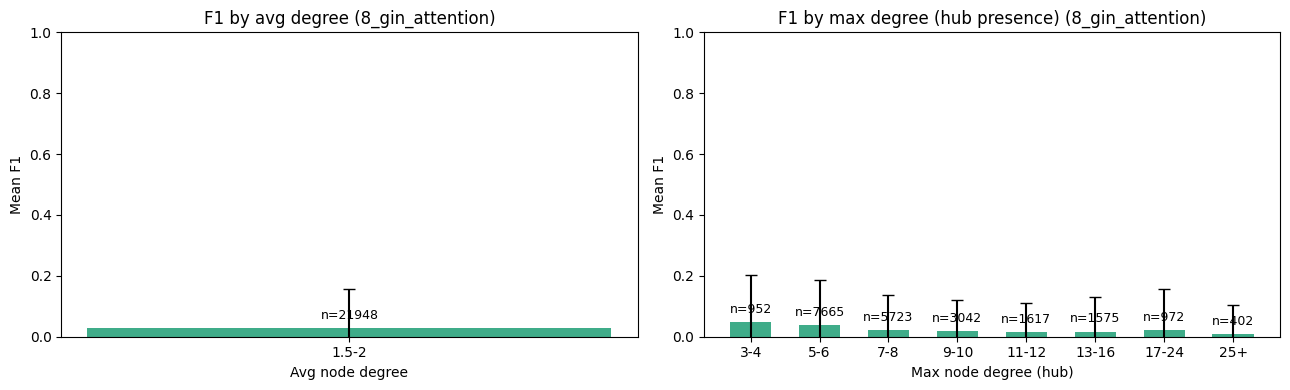


[8_gin_attention] degree stats
Average degree bins:
  bin  mean_f1   std_f1  count
1.5-2 0.027592 0.128012  21948

Max degree bins:
  bin  mean_f1   std_f1  count
  3-4 0.047778 0.156611    952
  5-6 0.038996 0.148984   7665
  7-8 0.022510 0.114518   5723
 9-10 0.018377 0.102335   3042
11-12 0.015690 0.096225   1617
13-16 0.016910 0.114518   1575
17-24 0.021056 0.135733    972
  25+ 0.009950 0.092892    402
Saved: error_analysis_outputs/8_gin_attention_error_analysis_degree.png


In [14]:
import matplotlib.pyplot as plt

for model_tag, model_df in analysis_results.items():
    df_plot = model_df.copy()

    # Bin by average degree (finer buckets)
    df_plot["avg_deg_bin"] = pd.cut(
        df_plot["avg_degree"],
        bins=[0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 5, 100],
        labels=["0-0.5", "0.5-1", "1-1.5", "1.5-2", "2-2.5", "2.5-3", "3-3.5", "3.5-4", "4-5", "5+"],
    )

    deg_stats = (
        df_plot.groupby("avg_deg_bin", observed=True)["f1"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    # Bin by max degree (hub nodes) (finer buckets)
    df_plot["max_deg_bin"] = pd.cut(
        df_plot["max_degree"],
        bins=[0, 2, 4, 6, 8, 10, 12, 16, 24, 9999],
        labels=["0-2", "3-4", "5-6", "7-8", "9-10", "11-12", "13-16", "17-24", "25+"],
    )

    hub_stats = (
        df_plot.groupby("max_deg_bin", observed=True)["f1"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for ax, stats, xlabel, title in [
        (axes[0], deg_stats, "Avg node degree", "F1 by avg degree"),
        (axes[1], hub_stats, "Max node degree (hub)", "F1 by max degree (hub presence)"),
    ]:
        stats.columns = ["bin", "mean_f1", "std_f1", "count"]
        bars = ax.bar(
            stats["bin"],
            stats["mean_f1"],
            yerr=stats["std_f1"],
            capsize=4,
            color="#1D9E75",
            alpha=0.85,
            width=0.6,
        )
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Mean F1")
        ax.set_title(f"{title} ({model_tag})")
        ax.set_ylim(0, 1)
        for bar, (_, row) in zip(bars, stats.iterrows()):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02,
                f"n={int(row['count'])}",
                ha="center",
                va="bottom",
                fontsize=9,
            )

    plt.tight_layout()
    output_path = analysis_output_dir / f"{model_tag}_error_analysis_degree.png"
    plt.savefig(output_path, dpi=150)
    plt.show()
    plt.close(fig)

    print(f"\n[{model_tag}] degree stats")
    print("Average degree bins:")
    print(deg_stats.to_string(index=False))
    print("\nMax degree bins:")
    print(hub_stats.to_string(index=False))
    print(f"Saved: {output_path}")

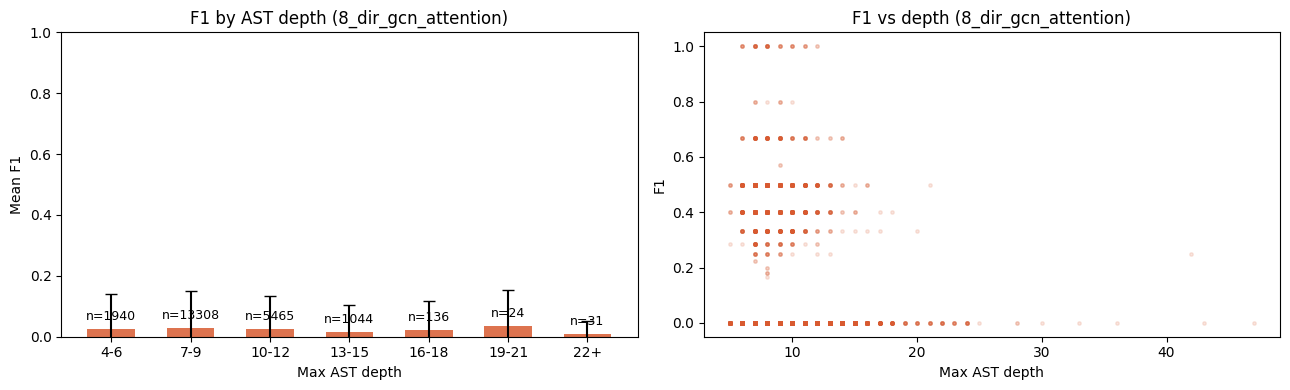


[8_dir_gcn_attention] depth stats
  bin  mean_f1   std_f1  count
  4-6 0.025896 0.113665   1940
  7-9 0.029924 0.118678  13308
10-12 0.024960 0.109652   5465
13-15 0.016619 0.087809   1044
16-18 0.021814 0.095355    136
19-21 0.034722 0.120177     24
  22+ 0.008065 0.044901     31
Saved: error_analysis_outputs/8_dir_gcn_attention_error_analysis_depth.png


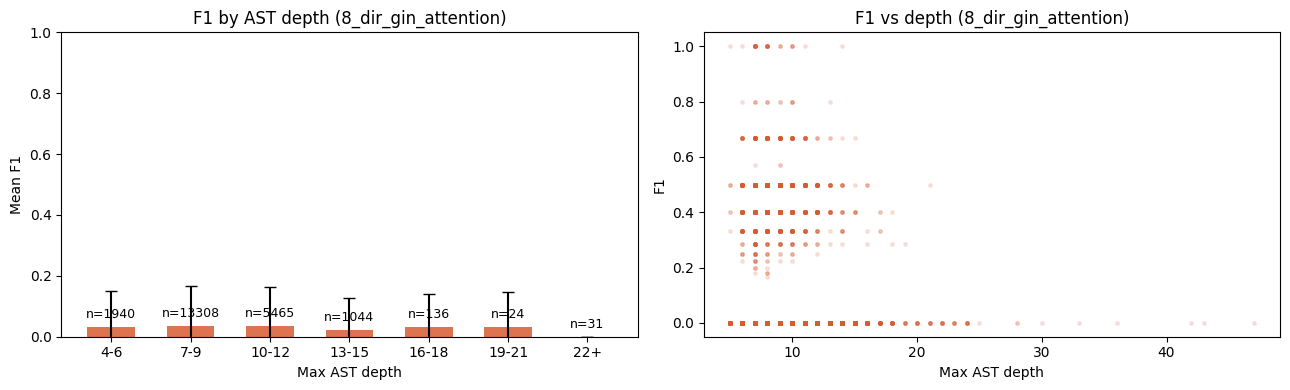


[8_dir_gin_attention] depth stats
  bin  mean_f1   std_f1  count
  4-6 0.031072 0.118932   1940
  7-9 0.036028 0.130355  13308
10-12 0.035362 0.126800   5465
13-15 0.022546 0.103473   1044
16-18 0.031408 0.108609    136
19-21 0.032738 0.115327     24
  22+ 0.000000 0.000000     31
Saved: error_analysis_outputs/8_dir_gin_attention_error_analysis_depth.png


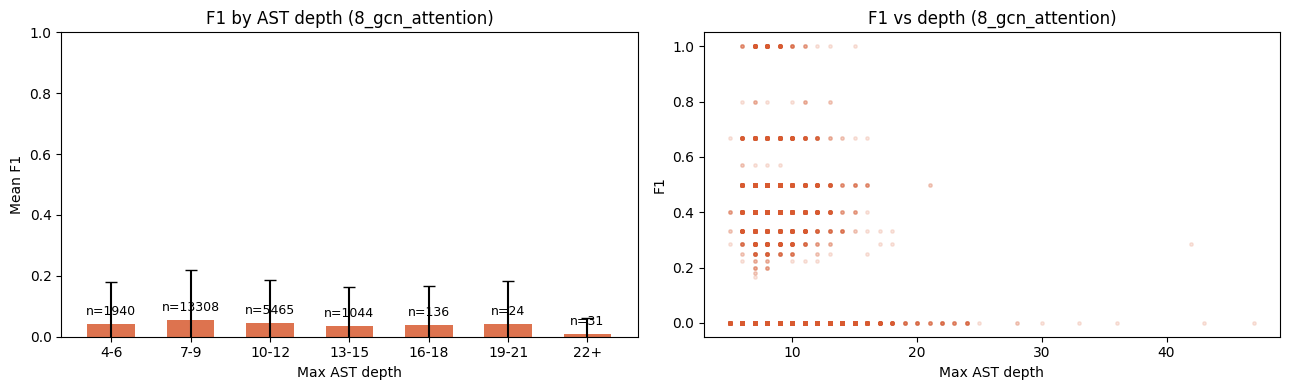


[8_gcn_attention] depth stats
  bin  mean_f1   std_f1  count
  4-6 0.041101 0.138091   1940
  7-9 0.056257 0.162651  13308
10-12 0.045381 0.142136   5465
13-15 0.035416 0.128318   1044
16-18 0.039618 0.127659    136
19-21 0.041667 0.141165     24
  22+ 0.009217 0.051316     31
Saved: error_analysis_outputs/8_gcn_attention_error_analysis_depth.png


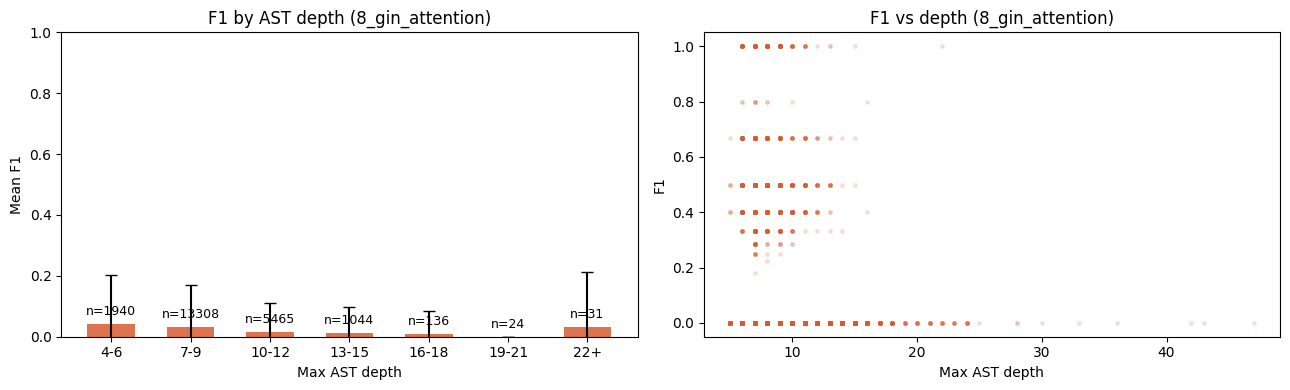


[8_gin_attention] depth stats
  bin  mean_f1   std_f1  count
  4-6 0.042337 0.159372   1940
  7-9 0.031812 0.136776  13308
10-12 0.015695 0.095899   5465
13-15 0.011622 0.085804   1044
16-18 0.008824 0.076469    136
19-21 0.000000 0.000000     24
  22+ 0.032258 0.179605     31
Saved: error_analysis_outputs/8_gin_attention_error_analysis_depth.png


In [15]:
import matplotlib.pyplot as plt

for model_tag, model_df in analysis_results.items():
    df_plot = model_df.copy()

    df_plot["depth_bin"] = pd.cut(
        df_plot["max_depth"],
        bins=[0, 3, 6, 9, 12, 15, 18, 21, 999],
        labels=["0-3", "4-6", "7-9", "10-12", "13-15", "16-18", "19-21", "22+"],
    )

    depth_stats = (
        df_plot.groupby("depth_bin", observed=True)["f1"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    depth_stats.columns = ["bin", "mean_f1", "std_f1", "count"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ax = axes[0]
    bars = ax.bar(
        depth_stats["bin"],
        depth_stats["mean_f1"],
        yerr=depth_stats["std_f1"],
        capsize=4,
        color="#D85A30",
        alpha=0.85,
        width=0.6,
    )
    ax.set_xlabel("Max AST depth")
    ax.set_ylabel("Mean F1")
    ax.set_title(f"F1 by AST depth ({model_tag})")
    ax.set_ylim(0, 1)
    for bar, (_, row) in zip(bars, depth_stats.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"n={int(row['count'])}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax = axes[1]
    ax.scatter(df_plot["max_depth"], df_plot["f1"], alpha=0.15, s=6, color="#D85A30")
    ax.set_xlabel("Max AST depth")
    ax.set_ylabel("F1")
    ax.set_title(f"F1 vs depth ({model_tag})")

    plt.tight_layout()
    output_path = analysis_output_dir / f"{model_tag}_error_analysis_depth.png"
    plt.savefig(output_path, dpi=150)
    plt.show()
    plt.close(fig)

    print(f"\n[{model_tag}] depth stats")
    print(depth_stats.to_string(index=False))
    print(f"Saved: {output_path}")

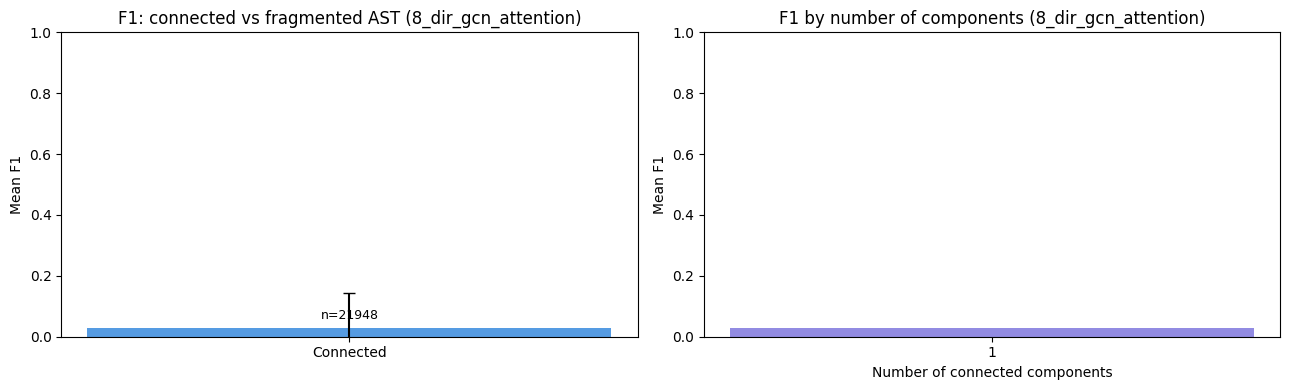


[8_dir_gcn_attention] connectivity stats
Connected ASTs: [[2.76229484e-02 2.19480000e+04]]
Fragmented ASTs: []
Saved: error_analysis_outputs/8_dir_gcn_attention_error_analysis_connectivity.png


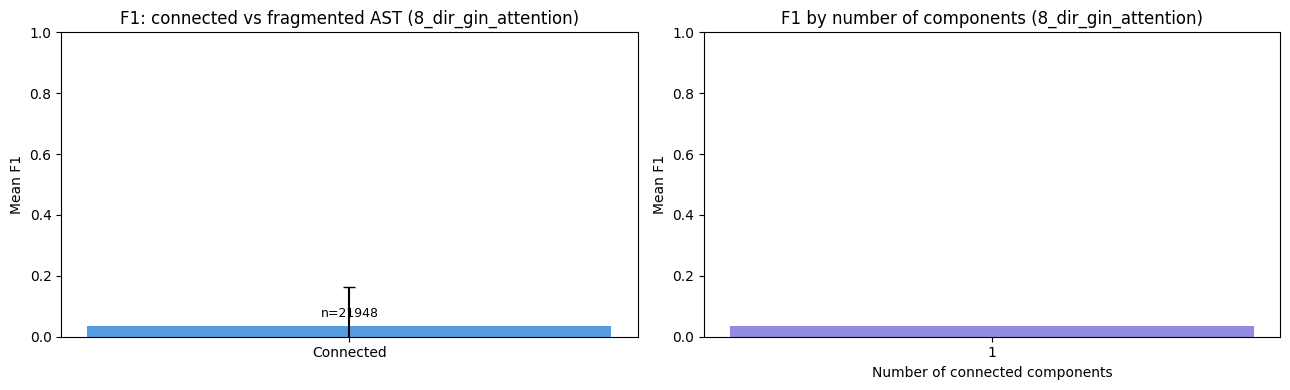


[8_dir_gin_attention] connectivity stats
Connected ASTs: [[3.46996351e-02 2.19480000e+04]]
Fragmented ASTs: []
Saved: error_analysis_outputs/8_dir_gin_attention_error_analysis_connectivity.png


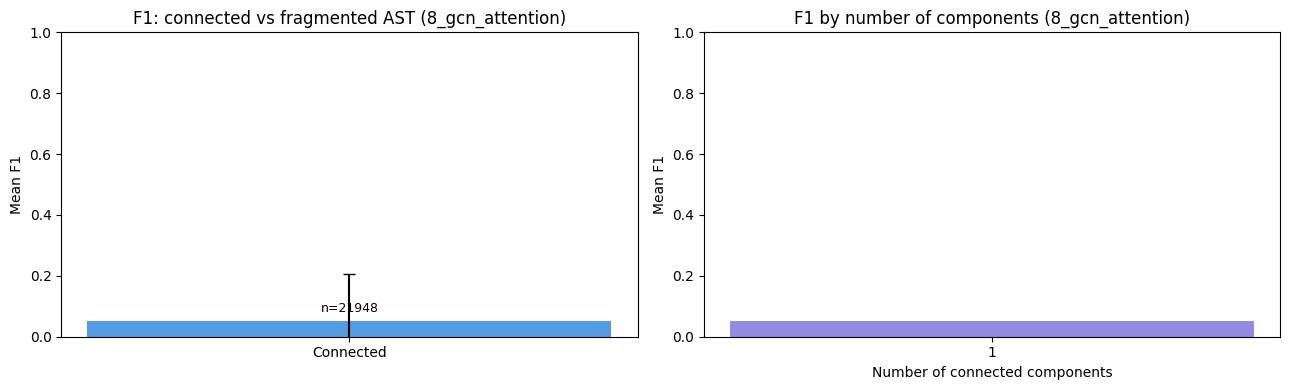


[8_gcn_attention] connectivity stats
Connected ASTs: [[5.10325337e-02 2.19480000e+04]]
Fragmented ASTs: []
Saved: error_analysis_outputs/8_gcn_attention_error_analysis_connectivity.png


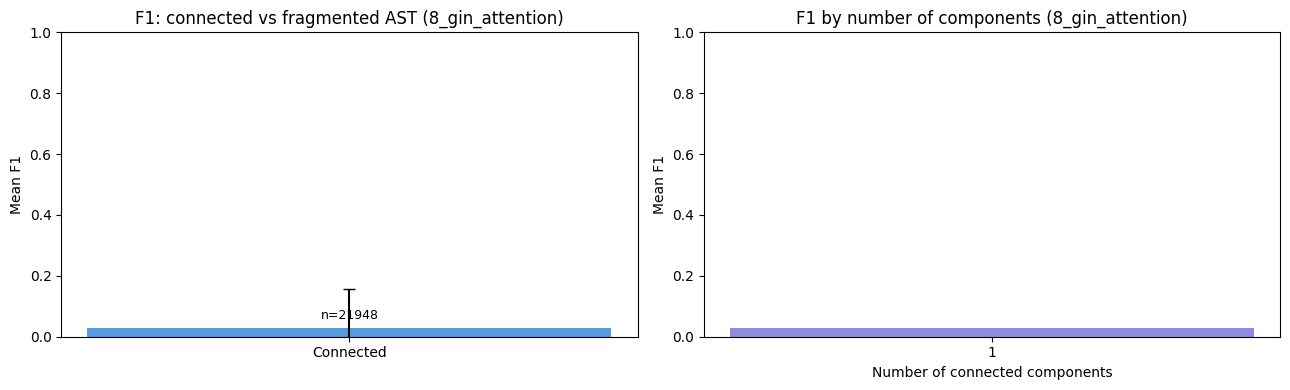


[8_gin_attention] connectivity stats
Connected ASTs: [[2.75920245e-02 2.19480000e+04]]
Fragmented ASTs: []
Saved: error_analysis_outputs/8_gin_attention_error_analysis_connectivity.png


In [17]:
import matplotlib.pyplot as plt

for model_tag, model_df in analysis_results.items():
    df_plot = model_df.copy()

    conn_stats = (
        df_plot.groupby("is_connected")["f1"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    conn_stats.columns = ["is_connected", "mean_f1", "std_f1", "count"]
    conn_stats["label"] = conn_stats["is_connected"].map({1: "Connected", 0: "Fragmented"})

    ncc_stats = (
        df_plot.groupby("num_components")["f1"]
        .agg(["mean", "count"])
        .reset_index()
    )
    ncc_stats.columns = ["num_components", "mean_f1", "count"]
    ncc_stats = ncc_stats[ncc_stats["count"] >= 5]  # filter tiny groups

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ax = axes[0]
    bars = ax.bar(
        conn_stats["label"],
        conn_stats["mean_f1"],
        yerr=conn_stats["std_f1"],
        capsize=4,
        color=["#378ADD", "#E24B4A"],
        alpha=0.85,
        width=0.4,
    )
    ax.set_ylabel("Mean F1")
    ax.set_title(f"F1: connected vs fragmented AST ({model_tag})")
    ax.set_ylim(0, 1)
    for bar, (_, row) in zip(bars, conn_stats.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"n={int(row['count'])}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax = axes[1]
    ax.bar(
        ncc_stats["num_components"].astype(str),
        ncc_stats["mean_f1"],
        color="#7F77DD",
        alpha=0.85,
        width=0.6,
    )
    ax.set_xlabel("Number of connected components")
    ax.set_ylabel("Mean F1")
    ax.set_title(f"F1 by number of components ({model_tag})")
    ax.set_ylim(0, 1)

    plt.tight_layout()
    output_path = analysis_output_dir / f"{model_tag}_error_analysis_connectivity.png"
    plt.savefig(output_path, dpi=150)
    plt.show()
    plt.close(fig)

    print(f"\n[{model_tag}] connectivity stats")
    print("Connected ASTs:", conn_stats[conn_stats["is_connected"] == 1][["mean_f1", "count"]].values)
    print("Fragmented ASTs:", conn_stats[conn_stats["is_connected"] == 0][["mean_f1", "count"]].values)
    print(f"Saved: {output_path}")

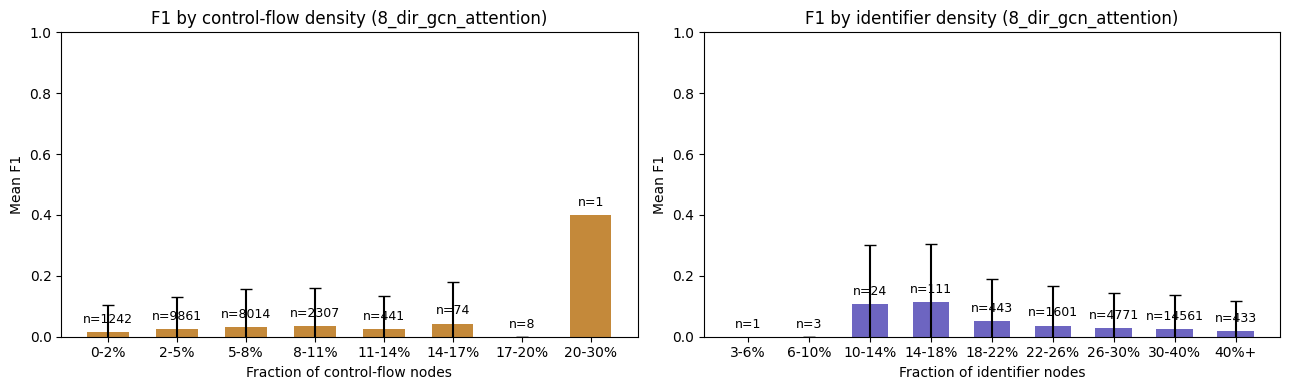


[8_dir_gcn_attention] node type composition stats
Control-flow bins:
   bin  mean_f1   std_f1  count
  0-2% 0.014842 0.087875   1242
  2-5% 0.023751 0.107526   9861
  5-8% 0.032374 0.122765   8014
 8-11% 0.034324 0.125509   2307
11-14% 0.025850 0.109507    441
14-17% 0.043243 0.135567     74
17-20% 0.000000 0.000000      8
20-30% 0.400000      NaN      1

Identifier bins:
   bin  mean_f1   std_f1  count
  3-6% 0.000000      NaN      1
 6-10% 0.000000 0.000000      3
10-14% 0.106250 0.193544     24
14-18% 0.115230 0.188761    111
18-22% 0.051623 0.138103    443
22-26% 0.036855 0.130328   1601
26-30% 0.028045 0.115852   4771
30-40% 0.025206 0.110569  14561
  40%+ 0.019015 0.098184    433
Saved: error_analysis_outputs/8_dir_gcn_attention_error_analysis_nodetype.png


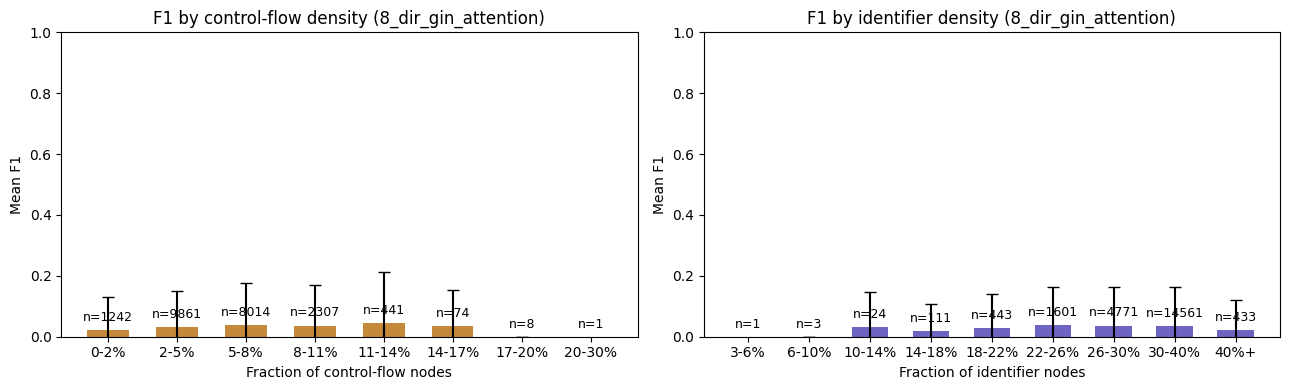


[8_dir_gin_attention] node type composition stats
Control-flow bins:
   bin  mean_f1   std_f1  count
  0-2% 0.023096 0.105990   1242
  2-5% 0.031213 0.119112   9861
  5-8% 0.039650 0.135498   8014
 8-11% 0.036617 0.131779   2307
11-14% 0.046107 0.165879    441
14-17% 0.034459 0.119624     74
17-20% 0.000000 0.000000      8
20-30% 0.000000      NaN      1

Identifier bins:
   bin  mean_f1   std_f1  count
  3-6% 0.000000      NaN      1
 6-10% 0.000000 0.000000      3
10-14% 0.032738 0.115327     24
14-18% 0.018919 0.087919    111
18-22% 0.028002 0.111542    443
22-26% 0.038065 0.126593   1601
26-30% 0.036660 0.126738   4771
30-40% 0.034394 0.128800  14561
  40%+ 0.022266 0.097324    433
Saved: error_analysis_outputs/8_dir_gin_attention_error_analysis_nodetype.png


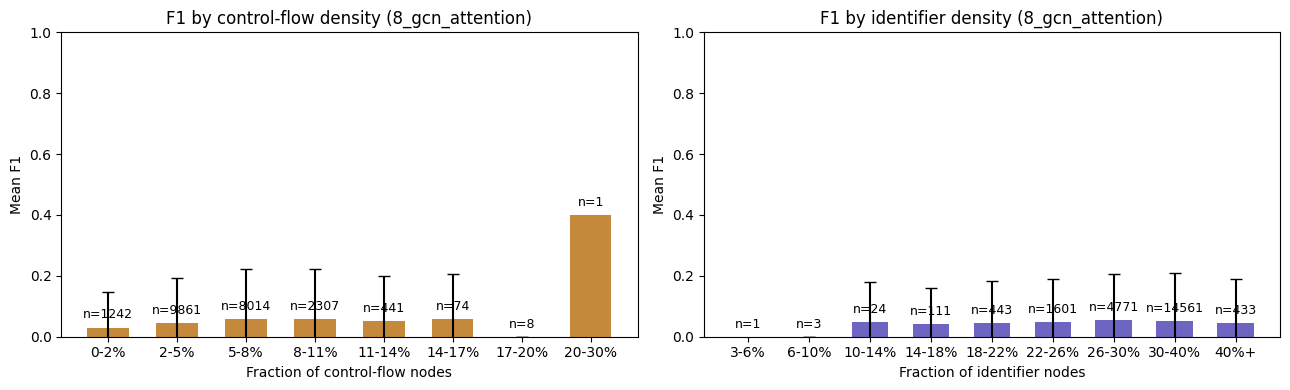


[8_gcn_attention] node type composition stats
Control-flow bins:
   bin  mean_f1   std_f1  count
  0-2% 0.030044 0.116227   1242
  2-5% 0.045023 0.148407   9861
  5-8% 0.059511 0.162712   8014
 8-11% 0.058184 0.163208   2307
11-14% 0.052133 0.146914    441
14-17% 0.057239 0.149505     74
17-20% 0.000000 0.000000      8
20-30% 0.400000      NaN      1

Identifier bins:
   bin  mean_f1   std_f1  count
  3-6% 0.000000      NaN      1
 6-10% 0.000000 0.000000      3
10-14% 0.046759 0.133010     24
14-18% 0.041613 0.117119    111
18-22% 0.046265 0.138219    443
22-26% 0.048283 0.141786   1601
26-30% 0.053738 0.151021   4771
30-40% 0.050840 0.157231  14561
  40%+ 0.045859 0.144470    433
Saved: error_analysis_outputs/8_gcn_attention_error_analysis_nodetype.png


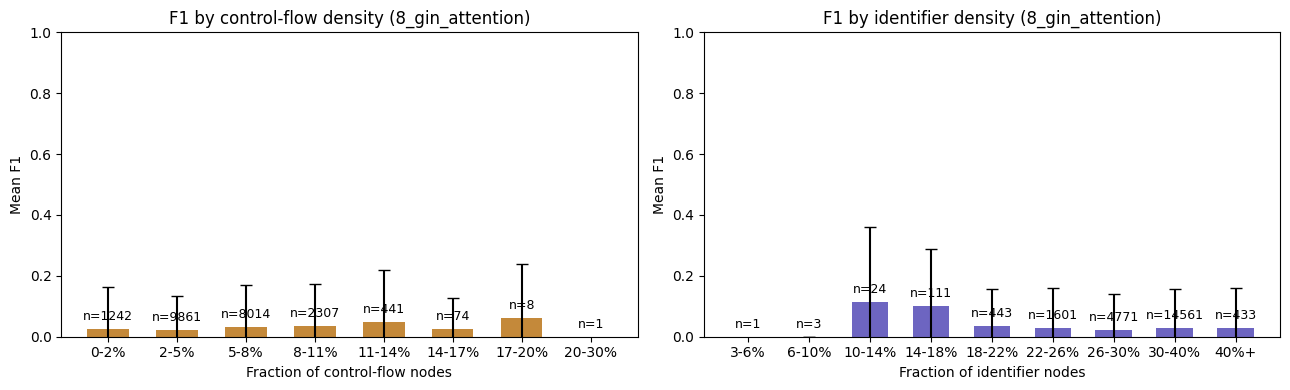


[8_gin_attention] node type composition stats
Control-flow bins:
   bin  mean_f1   std_f1  count
  0-2% 0.024436 0.137316   1242
  2-5% 0.020985 0.112480   9861
  5-8% 0.032830 0.137991   8014
 8-11% 0.035201 0.138696   2307
11-14% 0.049206 0.168894    441
14-17% 0.024324 0.103117     74
17-20% 0.062500 0.176777      8
20-30% 0.000000      NaN      1

Identifier bins:
   bin  mean_f1   std_f1  count
  3-6% 0.000000      NaN      1
 6-10% 0.000000 0.000000      3
10-14% 0.112500 0.249020     24
14-18% 0.101115 0.188388    111
18-22% 0.036268 0.119822    443
22-26% 0.027165 0.132838   1601
26-30% 0.022758 0.117252   4771
30-40% 0.028253 0.129897  14561
  40%+ 0.028022 0.132268    433
Saved: error_analysis_outputs/8_gin_attention_error_analysis_nodetype.png


In [18]:
import matplotlib.pyplot as plt

for model_tag, model_df in analysis_results.items():
    df_plot = model_df.copy()

    # Bin by fraction of structural (control-flow) nodes (finer buckets)
    df_plot["struct_bin"] = pd.cut(
        df_plot["frac_structural"],
        bins=[0, 0.02, 0.05, 0.08, 0.11, 0.14, 0.17, 0.2, 0.3, 1.0],
        labels=["0-2%", "2-5%", "5-8%", "8-11%", "11-14%", "14-17%", "17-20%", "20-30%", "30%+"],
    )

    # Bin by fraction of identifier nodes (finer buckets)
    df_plot["ident_bin"] = pd.cut(
        df_plot["frac_identifier"],
        bins=[0, 0.03, 0.06, 0.1, 0.14, 0.18, 0.22, 0.26, 0.3, 0.4, 1.0],
        labels=["0-3%", "3-6%", "6-10%", "10-14%", "14-18%", "18-22%", "22-26%", "26-30%", "30-40%", "40%+"],
    )

    struct_stats = (
        df_plot.groupby("struct_bin", observed=True)["f1"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    ident_stats = (
        df_plot.groupby("ident_bin", observed=True)["f1"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for ax, stats, xlabel, title, color in [
        (
            axes[0],
            struct_stats,
            "Fraction of control-flow nodes",
            "F1 by control-flow density",
            "#BA7517",
        ),
        (
            axes[1],
            ident_stats,
            "Fraction of identifier nodes",
            "F1 by identifier density",
            "#534AB7",
        ),
    ]:
        stats.columns = ["bin", "mean_f1", "std_f1", "count"]
        bars = ax.bar(
            stats["bin"],
            stats["mean_f1"],
            yerr=stats["std_f1"],
            capsize=4,
            color=color,
            alpha=0.85,
            width=0.6,
        )
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Mean F1")
        ax.set_title(f"{title} ({model_tag})")
        ax.set_ylim(0, 1)
        for bar, (_, row) in zip(bars, stats.iterrows()):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02,
                f"n={int(row['count'])}",
                ha="center",
                va="bottom",
                fontsize=9,
            )

    plt.tight_layout()
    output_path = analysis_output_dir / f"{model_tag}_error_analysis_nodetype.png"
    plt.savefig(output_path, dpi=150)
    plt.show()
    plt.close(fig)

    print(f"\n[{model_tag}] node type composition stats")
    print("Control-flow bins:")
    print(struct_stats.to_string(index=False))
    print("\nIdentifier bins:")
    print(ident_stats.to_string(index=False))
    print(f"Saved: {output_path}")

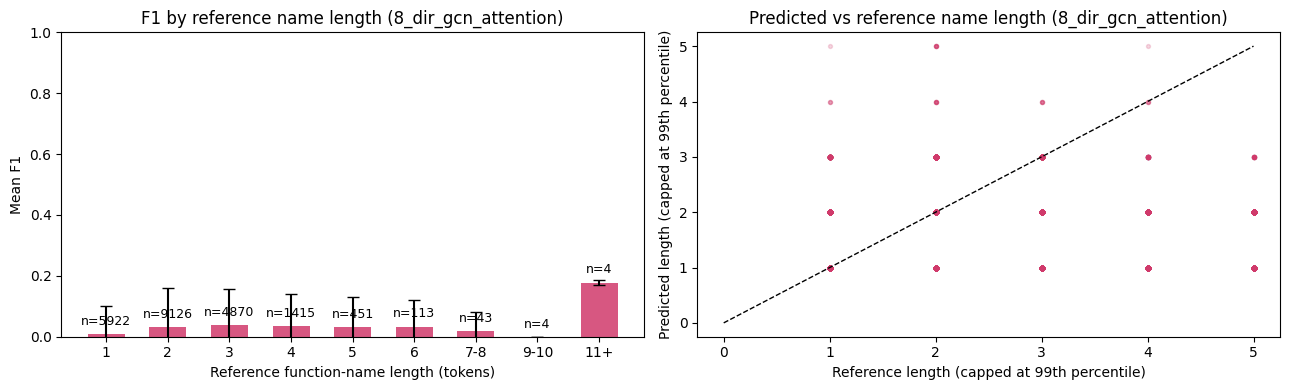


[8_dir_gcn_attention] name length stats
 bin  mean_f1   std_f1  count
   1 0.010075 0.091596   5922
   2 0.032563 0.126992   9126
   3 0.036910 0.118243   4870
   4 0.034895 0.104284   1415
   5 0.033180 0.096103    451
   6 0.033502 0.086075    113
 7-8 0.019638 0.062141     43
9-10 0.000000 0.000000      4
 11+ 0.178030 0.007576      4
Mean(pred_len - ref_len): -0.668
Saved: error_analysis_outputs/8_dir_gcn_attention_error_analysis_name_length.png


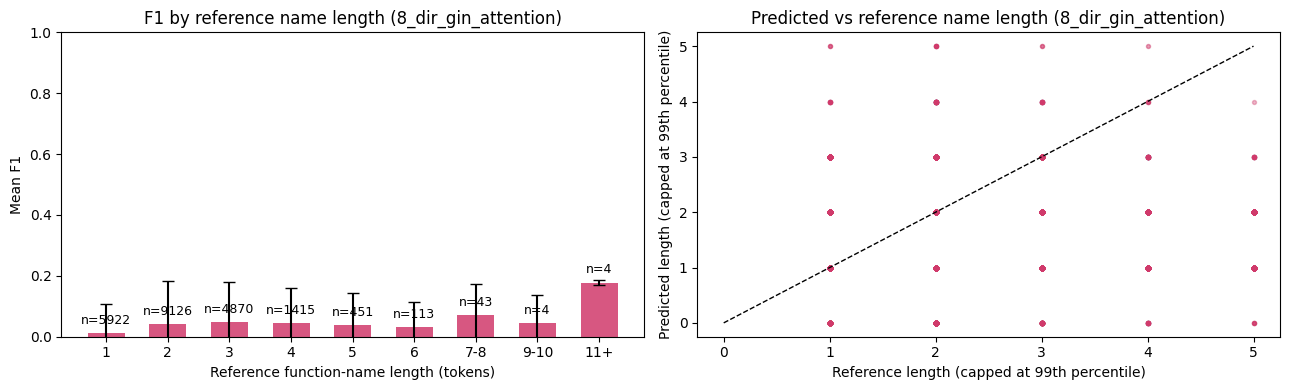


[8_dir_gin_attention] name length stats
 bin  mean_f1   std_f1  count
   1 0.011651 0.094339   5922
   2 0.041254 0.142684   9126
   3 0.046883 0.133265   4870
   4 0.044353 0.116426   1415
   5 0.038877 0.103204    451
   6 0.031360 0.083933    113
 7-8 0.070930 0.103580     43
9-10 0.045455 0.090909      4
 11+ 0.178030 0.007576      4
Mean(pred_len - ref_len): -0.529
Saved: error_analysis_outputs/8_dir_gin_attention_error_analysis_name_length.png


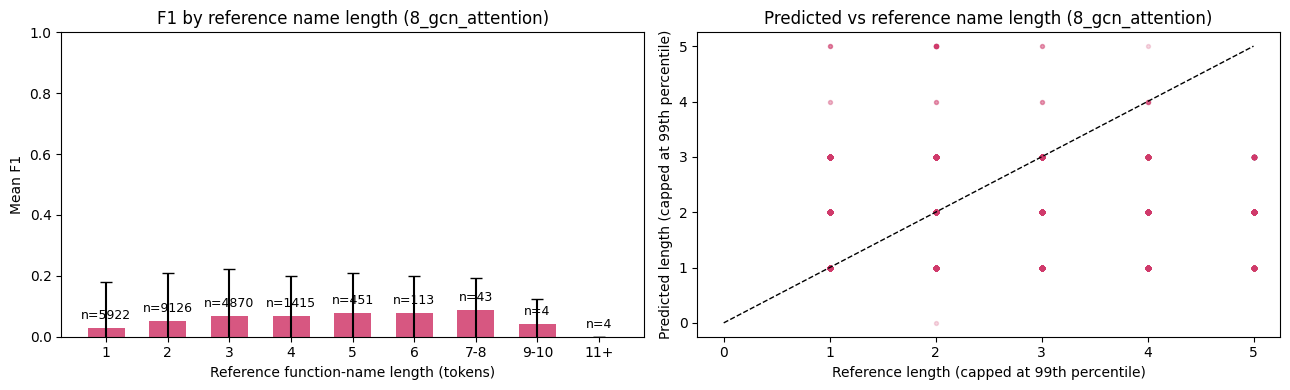


[8_gcn_attention] name length stats
 bin  mean_f1   std_f1  count
   1 0.027159 0.151149   5922
   2 0.052535 0.157846   9126
   3 0.069354 0.154575   4870
   4 0.066566 0.134529   1415
   5 0.077922 0.131992    451
   6 0.077399 0.121026    113
 7-8 0.088302 0.106025     43
9-10 0.041667 0.083333      4
 11+ 0.000000 0.000000      4
Mean(pred_len - ref_len): -0.367
Saved: error_analysis_outputs/8_gcn_attention_error_analysis_name_length.png


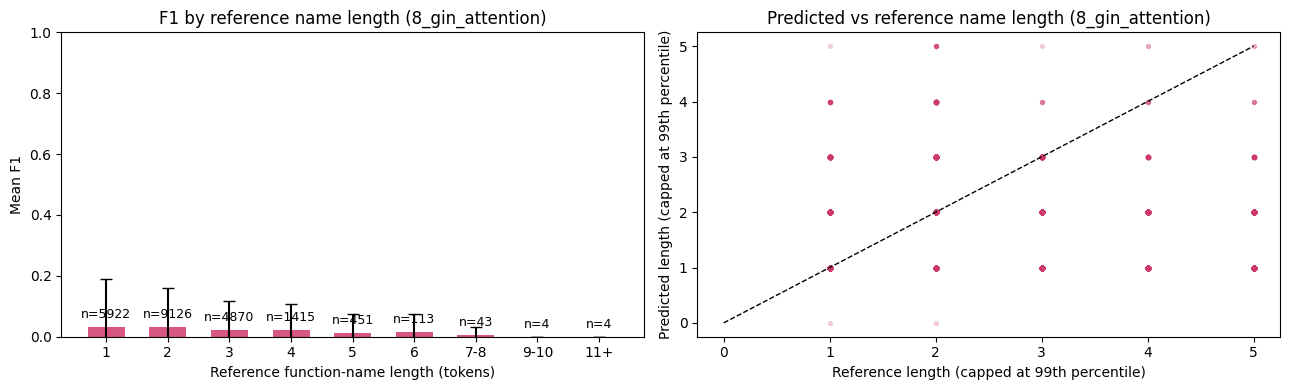


[8_gin_attention] name length stats
 bin  mean_f1   std_f1  count
   1 0.030564 0.159854   5922
   2 0.030565 0.128900   9126
   3 0.021944 0.094570   4870
   4 0.022038 0.086528   1415
   5 0.012582 0.061004    451
   6 0.015487 0.060533    113
 7-8 0.004228 0.027727     43
9-10 0.000000 0.000000      4
 11+ 0.000000 0.000000      4
Mean(pred_len - ref_len): -0.645
Saved: error_analysis_outputs/8_gin_attention_error_analysis_name_length.png


In [19]:
# Analysis 6: Name length bias
import matplotlib.pyplot as plt
import numpy as np

for model_tag, model_df in analysis_results.items():
    df_plot = model_df.copy()

    df_plot["ref_len_bin"] = pd.cut(
        df_plot["ref_len"],
        bins=[0, 1, 2, 3, 4, 5, 6, 8, 10, 999],
        labels=["1", "2", "3", "4", "5", "6", "7-8", "9-10", "11+"],
    )

    len_stats = (
        df_plot.groupby("ref_len_bin", observed=True)["f1"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    len_stats.columns = ["bin", "mean_f1", "std_f1", "count"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ax = axes[0]
    bars = ax.bar(
        len_stats["bin"],
        len_stats["mean_f1"],
        yerr=len_stats["std_f1"],
        capsize=4,
        color="#D03A6B",
        alpha=0.85,
        width=0.6,
    )
    ax.set_xlabel("Reference function-name length (tokens)")
    ax.set_ylabel("Mean F1")
    ax.set_title(f"F1 by reference name length ({model_tag})")
    ax.set_ylim(0, 1)
    for bar, (_, row) in zip(bars, len_stats.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"n={int(row['count'])}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax = axes[1]
    max_len_cap = int(
        np.percentile(np.concatenate([df_plot["ref_len"].values, df_plot["pred_len"].values]), 99)
    )
    ax.scatter(
        df_plot["ref_len"].clip(upper=max_len_cap),
        df_plot["pred_len"].clip(upper=max_len_cap),
        alpha=0.2,
        s=8,
        color="#D03A6B",
    )
    ax.plot([0, max_len_cap], [0, max_len_cap], linestyle="--", color="black", linewidth=1)
    ax.set_xlabel("Reference length (capped at 99th percentile)")
    ax.set_ylabel("Predicted length (capped at 99th percentile)")
    ax.set_title(f"Predicted vs reference name length ({model_tag})")

    plt.tight_layout()
    output_path = analysis_output_dir / f"{model_tag}_error_analysis_name_length.png"
    plt.savefig(output_path, dpi=150)
    plt.show()
    plt.close(fig)

    print(f"\n[{model_tag}] name length stats")
    print(len_stats.to_string(index=False))
    print(f"Mean(pred_len - ref_len): {df_plot['len_gap'].mean():.3f}")
    print(f"Saved: {output_path}")

In [20]:
from scipy import stats as scipy_stats

features = [
    "num_nodes",
    "avg_degree",
    "max_degree",
    "max_depth",
    "branching",
    "frac_structural",
    "frac_identifier",
    "frac_literal",
    "ref_len",
    "pred_len",
    "len_gap",
]

correlation_tables = {}

for model_tag, model_df in analysis_results.items():
    rows = []
    for feat in features:
        r, p = scipy_stats.spearmanr(model_df[feat], model_df["f1"])
        rows.append(
            {
                "feature": feat,
                "spearman_r": round(r, 3),
                "p_value": round(p, 4),
                "significant": "*" if p < 0.05 else "",
            }
        )

    corr_df = pd.DataFrame(rows).sort_values("spearman_r", key=abs, ascending=False)
    correlation_tables[model_tag] = corr_df

    output_csv = analysis_output_dir / f"{model_tag}_spearman_f1.csv"
    corr_df.to_csv(output_csv, index=False)

    print(f"\n[{model_tag}] Spearman correlation with F1:")
    print(corr_df.to_string(index=False))
    print(f"Saved: {output_csv}")


[8_dir_gcn_attention] Spearman correlation with F1:
        feature  spearman_r  p_value significant
       pred_len       0.218   0.0000           *
        ref_len       0.127   0.0000           *
     max_degree      -0.071   0.0000           *
     avg_degree      -0.069   0.0000           *
      num_nodes      -0.069   0.0000           *
      branching      -0.069   0.0000           *
frac_structural       0.055   0.0000           *
frac_identifier      -0.038   0.0000           *
      max_depth      -0.032   0.0000           *
   frac_literal       0.027   0.0000           *
        len_gap      -0.003   0.6435            
Saved: error_analysis_outputs/8_dir_gcn_attention_spearman_f1.csv

[8_dir_gin_attention] Spearman correlation with F1:
        feature  spearman_r  p_value significant
       pred_len       0.156   0.0000           *
        ref_len       0.142   0.0000           *
        len_gap      -0.042   0.0000           *
frac_structural       0.035   0.0000        